# Skyline Airlines — Exploratory Data Analysis

## Objective

Explore passenger, flight, service, complaint, revenue and satisfaction
patterns in the Skyline Airlines dataset.

The analysis will identify:
- Data quality issues
- Passenger segment patterns
- Satisfaction drivers
- Operational relationships
- Service quality weaknesses
- Complaint patterns
- Revenue relationships
- Candidate features for machine learning

The finalized PostgreSQL warehouse is used as the primary analytical source
to maintain consistency with the Power BI dashboard.

## 1. Importing Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, text

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. PostgreSQL Connection

In [5]:
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "skyline_airlines"
DB_USER = "postgres"
DB_PASSWORD = "postgres"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}"
    f"@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

print("PostgreSQL engine created.")

PostgreSQL engine created.


In [6]:
#Testing the connection

with engine.connect() as connection:
    result = connection.execute(text("SELECT 1"))
    print("PostgreSQL connection successful:", result.scalar())

PostgreSQL connection successful: 1


In [8]:
#Checking for all the schemas and tables

query = """
SELECT
    table_schema,
    table_name
FROM information_schema.tables
WHERE table_schema IN ('staging', 'warehouse')
ORDER BY table_schema, table_name;
"""

tables = pd.read_sql(query, engine)

tables

,table_schema,table_name
0,staging,stg_bookings
1,staging,stg_feedback
2,staging,stg_flights
3,staging,stg_passengers
4,staging,stg_service
5,warehouse,dim_aircraft
6,warehouse,dim_airport
7,warehouse,dim_booking
8,warehouse,dim_cabin
9,warehouse,dim_date


In [10]:
fact_columns = """
SELECT
    column_name,
    data_type
FROM information_schema.columns
WHERE table_schema = 'warehouse'
  AND table_name = 'fact_passenger_experience'
ORDER BY ordinal_position;
"""

fact_schema = pd.read_sql(fact_columns, engine)

fact_schema

,column_name,data_type
0,experiencekey,integer
1,passengerkey,integer
2,flightkey,integer
3,bookingkey,integer
4,cabinkey,integer
5,datekey,integer
6,delay,integer
7,fare,numeric
8,ancillaryrevenue,numeric
9,checkinrating,integer


In [11]:
passenger_columns = """
SELECT
    column_name,
    data_type
FROM information_schema.columns
WHERE table_schema = 'warehouse'
  AND table_name = 'dim_passenger'
ORDER BY ordinal_position;
"""

pd.read_sql(passenger_columns, engine)

,column_name,data_type
0,passengerkey,integer
1,passengerid,character varying
2,age,integer
3,agegroup,character varying
4,gender,character varying
5,customertype,character varying
6,loyaltytier,character varying
7,traveltype,character varying
8,country,character varying


In [12]:
flight_columns = """
SELECT
    column_name,
    data_type
FROM information_schema.columns
WHERE table_schema = 'warehouse'
  AND table_name = 'dim_flight'
ORDER BY ordinal_position;
"""

pd.read_sql(flight_columns, engine)

,column_name,data_type
0,flightkey,integer
1,flightid,character varying
2,route,character varying
3,originairportkey,integer
4,destinationairportkey,integer
5,aircraftkey,integer
6,duration,integer
7,distance,integer
8,routetype,character varying
9,departuretime,timestamp without time zone


In [13]:
booking_columns = """
SELECT
    column_name,
    data_type
FROM information_schema.columns
WHERE table_schema = 'warehouse'
  AND table_name = 'dim_booking'
ORDER BY ordinal_position;
"""

pd.read_sql(booking_columns, engine)

,column_name,data_type
0,bookingkey,integer
1,bookingid,character varying
2,passengerid,character varying
3,flightid,character varying
4,bookingdate,timestamp without time zone
5,bookingchannel,character varying


## 3. Build Analytical Dataset

- The EDA dataset combines the passenger, flight, booking and passenger-experience
fact tables into a single analytical DataFrame.
- The warehouse remains the source of truth so that Python analysis stays
consistent with the Power BI model.

In [14]:
eda_query = """
SELECT
    f.experiencekey,

    -- Passenger information
    p.passengerid,
    p.age,
    p.agegroup,
    p.gender,
    p.country,
    p.customertype,
    p.loyaltytier,
    p.traveltype,

    -- Flight information
    fl.flightid,
    fl.route,
    fl.routetype,
    fl.duration,
    fl.distance,
    fl.departuretime,
    fl.arrivaltime,

    -- Booking information
    b.bookingid,
    b.bookingdate,
    b.bookingchannel,

    -- Passenger experience
    f.delay,
    f.checkinrating,
    f.boardingrating,
    f.crewrating,
    f.seatcomfort,
    f.wifi,
    f.entertainment,
    f.food,
    f.cleanliness,
    f.baggagehandling,

    -- Customer outcome
    f.nps,
    f.overallsatisfaction,
    f.complainttype,

    -- Revenue
    f.fare,
    f.ancillaryrevenue,

    -- Warehouse keys
    f.cabinkey,
    f.datekey

FROM warehouse.fact_passenger_experience f

LEFT JOIN warehouse.dim_passenger p
    ON f.passengerkey = p.passengerkey

LEFT JOIN warehouse.dim_flight fl
    ON f.flightkey = fl.flightkey

LEFT JOIN warehouse.dim_booking b
    ON f.bookingkey = b.bookingkey
"""

eda_df = pd.read_sql(eda_query, engine)

print("EDA dataset loaded successfully.")
print("Rows:", len(eda_df))
print("Columns:", len(eda_df.columns))

EDA dataset loaded successfully.
Rows: 5000
Columns: 36


## 4. Inspecting the dataset

In [15]:
eda_df.head()

,experiencekey,passengerid,age,agegroup,gender,country,customertype,loyaltytier,traveltype,flightid,route,routetype,duration,distance,departuretime,arrivaltime,bookingid,bookingdate,bookingchannel,delay,checkinrating,boardingrating,crewrating,seatcomfort,wifi,entertainment,food,cleanliness,baggagehandling,nps,overallsatisfaction,complainttype,fare,ancillaryrevenue,cabinkey,datekey
0,20003,P000701,40,36-50,Male,India,Returning,Silver,Leisure,F00701,GOI-BOM,Domestic,186,561,2026-01-01 17:53:00,2026-01-01 20:59:00,B000701,2025-12-09 17:53:00,Corporate,-12,5,5,4,4,4,4,5,5,4,10,Satisfied,None,11200.0,2412.0,1,20251209
1,20004,P003617,41,36-50,Female,India,First-time,None,Leisure,F00617,BOM-DXB,International,177,1870,2026-01-03 09:20:00,2026-01-03 12:25:00,B003617,2026-02-27 09:20:00,Mobile App,-12,5,5,4,5,5,4,5,5,4,7,Satisfied,None,19840.0,1765.0,1,20260227
2,20005,P001310,18,18-25,Female,UK,Returning,None,Business,F00310,AMD-BLR,Domestic,143,1144,2026-01-03 21:01:00,2026-01-03 23:24:00,B001310,2026-02-15 21:01:00,Website,7,4,4,3,5,5,4,3,4,5,9,Satisfied,None,15050.0,979.0,1,20260215
3,20006,P003209,56,51+,Male,India,First-time,Platinum,Business,F00209,BOM-MAA,Domestic,152,919,2026-01-02 12:48:00,2026-01-02 15:20:00,B003209,2026-01-30 12:48:00,Corporate,46,3,3,4,3,3,3,3,5,3,8,Satisfied,None,13570.0,2809.0,1,20260130
4,20007,P001311,32,26-35,Female,India,Returning,Gold,Leisure,F00311,GOI-BOM,Domestic,152,487,2026-01-03 12:07:00,2026-01-03 14:39:00,B001311,2026-02-12 12:07:00,Ota,16,4,3,4,3,3,5,4,4,3,9,Satisfied,None,10710.0,2642.0,1,20260212


In [16]:
eda_df.shape

(5000, 36)

In [17]:
eda_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   experiencekey        5000 non-null   int64         
 1   passengerid          5000 non-null   object        
 2   age                  5000 non-null   int64         
 3   agegroup             5000 non-null   object        
 4   gender               5000 non-null   object        
 5   country              5000 non-null   object        
 6   customertype         5000 non-null   object        
 7   loyaltytier          5000 non-null   object        
 8   traveltype           5000 non-null   object        
 9   flightid             5000 non-null   object        
 10  route                5000 non-null   object        
 11  routetype            5000 non-null   object        
 12  duration             5000 non-null   int64         
 13  distance             5000 non-nul

In [18]:
eda_df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
experiencekey,5000.0,NaN,NaN,NaN,22502.5,20003.0,21252.75,22502.5,23752.25,25002.0,1443.520003
passengerid,5000,5000,P000701,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,5000.0,NaN,NaN,NaN,38.6736,18.0,30.0,38.0,47.0,94.0,12.173475
agegroup,5000,4,36-50,2076,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,5000,2,Female,2526,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,5000,6,India,4517,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customertype,5000,2,Returning,3262,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loyaltytier,5000,4,None,2399,NaN,NaN,NaN,NaN,NaN,NaN,NaN
traveltype,5000,2,Leisure,2999,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flightid,5000,1000,F00701,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
# Checking for duplicate passenger records

print(
    "Duplicate experience records:",
    eda_df["experiencekey"].duplicated().sum()
)

Duplicate experience records: 0


In [22]:
print(
    "Unique experience records:",
    eda_df["experiencekey"].nunique()
)

print(
    "Total rows:",
    len(eda_df)
)

Unique experience records: 5000
Total rows: 5000


In [24]:
# Checking for missing values

missing = (
    eda_df.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_percentage = (
    eda_df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_report = pd.DataFrame({
    "missing_count": missing,
    "missing_percentage": missing_percentage.round(2)
})

missing_report

,missing_count,missing_percentage
complainttype,4075,81.5
experiencekey,0,0.0
food,0,0.0
checkinrating,0,0.0
boardingrating,0,0.0
crewrating,0,0.0
seatcomfort,0,0.0
wifi,0,0.0
entertainment,0,0.0
cleanliness,0,0.0


In [26]:
# Checking Categorical Distributions
categorical_columns = [
    "gender",
    "customertype",
    "loyaltytier",
    "traveltype",
    "routetype",
    "bookingchannel",
    "overallsatisfaction",
    "complainttype"
]

for col in categorical_columns:
    print(f"\n{'=' * 50}")
    print(col.upper())
    print(f"{'=' * 50}")
    print(eda_df[col].value_counts(dropna=False))


GENDER
gender
Female    2526
Male      2474
Name: count, dtype: int64

CUSTOMERTYPE
customertype
Returning     3262
First-time    1738
Name: count, dtype: int64

LOYALTYTIER
loyaltytier
None        2399
Silver      1135
Gold        1011
Platinum     455
Name: count, dtype: int64

TRAVELTYPE
traveltype
Leisure     2999
Business    2001
Name: count, dtype: int64

ROUTETYPE
routetype
Domestic         3500
International    1500
Name: count, dtype: int64

BOOKINGCHANNEL
bookingchannel
Corporate       1021
Mobile App      1009
Ota             1002
Website          992
Travel Agent     976
Name: count, dtype: int64

OVERALLSATISFACTION
overallsatisfaction
Satisfied      4084
Unsatisfied     916
Name: count, dtype: int64

COMPLAINTTYPE
complainttype
None                 4075
Seat Comfort          113
WiFi                  110
Baggage Handling      106
Entertainment         105
Boarding Process       96
Check-In Process       92
Food Quality           90
Crew Behaviour         88
Cabin Cleanli

In [27]:
# EDA Summary

eda_summary = pd.DataFrame({
    "Metric": [
        "Total Experiences",
        "Unique Passengers",
        "Unique Flights",
        "Unique Routes",
        "Satisfied Passengers",
        "Unsatisfied Passengers",
        "Complaints",
        "Average Delay",
        "Average NPS",
        "Average Fare",
        "Total Revenue"
    ],
    "Value": [
        len(eda_df),
        eda_df["passengerid"].nunique(),
        eda_df["flightid"].nunique(),
        eda_df["route"].nunique(),
        (eda_df["overallsatisfaction"] == "Satisfied").sum(),
        (eda_df["overallsatisfaction"] != "Satisfied").sum(),
        eda_df["complainttype"].notna().sum(),
        eda_df["delay"].mean(),
        eda_df["nps"].mean(),
        eda_df["fare"].mean(),
        eda_df["fare"].sum() + eda_df["ancillaryrevenue"].sum()
    ]
})

eda_summary

,Metric,Value
0,Total Experiences,5.000000e+03
1,Unique Passengers,5.000000e+03
2,Unique Flights,1.000000e+03
3,Unique Routes,2.300000e+01
4,Satisfied Passengers,4.084000e+03
5,Unsatisfied Passengers,9.160000e+02
6,Complaints,9.250000e+02
7,Average Delay,1.939500e+01
8,Average NPS,7.607000e+00
9,Average Fare,9.551214e+03


In [28]:
cabin_columns = """
SELECT
    column_name,
    data_type
FROM information_schema.columns
WHERE table_schema = 'warehouse'
  AND table_name = 'dim_cabin'
ORDER BY ordinal_position;
"""

cabin_schema = pd.read_sql(cabin_columns, engine)

cabin_schema

,column_name,data_type
0,cabinkey,integer
1,cabinclass,character varying


In [32]:
# Adding cabin class to our dataset

cabin_query = """
SELECT
    cabinkey,
    cabinclass
FROM warehouse.dim_cabin
ORDER BY cabinkey;
"""

cabin_df = pd.read_sql(cabin_query, engine)

cabin_df

,cabinkey,cabinclass
0,1,Business
1,2,Economy
2,3,First
3,4,Premium Economy


In [30]:
eda_df = eda_df.merge(
    cabin_df,
    on="cabinkey",
    how="left"
)

print("Cabin class added successfully.")
print(eda_df["cabinclass"].value_counts())

Cabin class added successfully.
cabinclass
Economy            3650
Business            674
Premium Economy     485
First               191
Name: count, dtype: int64


In [31]:
print("Dataset shape:", eda_df.shape)

Dataset shape: (5000, 37)


## 4. Numerical Variable Distributions
We examine the distributions of passenger demographics, operational
metrics, service ratings, NPS and financial variables to identify
patterns and potential outliers.

In [34]:
# Creating numerical summary

numeric_columns = [
    "age",
    "duration",
    "distance",
    "delay",
    "checkinrating",
    "boardingrating",
    "crewrating",
    "seatcomfort",
    "wifi",
    "entertainment",
    "food",
    "cleanliness",
    "baggagehandling",
    "nps",
    "fare",
    "ancillaryrevenue"
]

numeric_summary = eda_df[numeric_columns].describe().T

numeric_summary

,count,mean,std,min,25%,50%,75%,max
age,5000.0,38.6736,12.173475,18.0,30.0,38.0,47.00,94.0
duration,5000.0,170.0220,98.875613,70.0,112.0,149.0,184.00,605.0
distance,5000.0,1813.9500,1280.086195,454.0,1029.0,1600.0,2070.50,7268.0
delay,5000.0,19.3950,31.582693,-12.0,0.0,17.0,33.00,419.0
checkinrating,5000.0,3.8292,0.871883,1.0,3.0,4.0,4.00,5.0
boardingrating,5000.0,3.6896,0.928776,1.0,3.0,4.0,4.00,5.0
crewrating,5000.0,4.0148,0.826267,1.0,3.0,4.0,5.00,5.0
seatcomfort,5000.0,3.6006,0.959825,1.0,3.0,4.0,4.00,5.0
wifi,5000.0,3.3924,1.057093,1.0,3.0,3.0,4.00,5.0
entertainment,5000.0,3.5240,1.013326,1.0,3.0,4.0,4.00,5.0


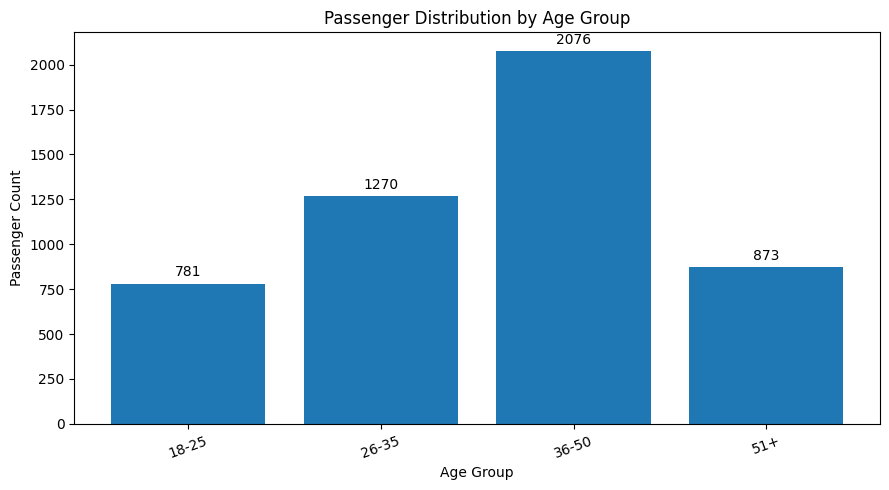

In [41]:
# Passenger Distribution by Age Group

age_counts = (
    eda_df["agegroup"]
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    age_counts.index,
    age_counts.values
)

ax.bar_label(bars, fmt="%d", padding=3)

ax.set_title("Passenger Distribution by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Passenger Count")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

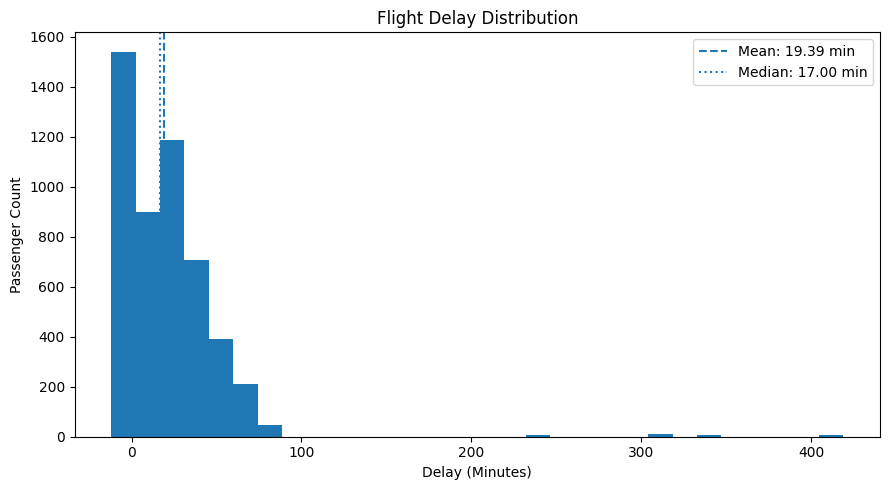

In [61]:
# 2. Flight Delay Distribution

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    eda_df["delay"],
    bins=30
)

mean_delay = eda_df["delay"].mean()
median_delay = eda_df["delay"].median()

ax.axvline(
    mean_delay,
    linestyle="--",
    label=f"Mean: {mean_delay:.2f} min"
)

ax.axvline(
    median_delay,
    linestyle=":",
    label=f"Median: {median_delay:.2f} min"
)

ax.set_title("Flight Delay Distribution")
ax.set_xlabel("Delay (Minutes)")
ax.set_ylabel("Passenger Count")

ax.legend()

plt.tight_layout()
plt.show()

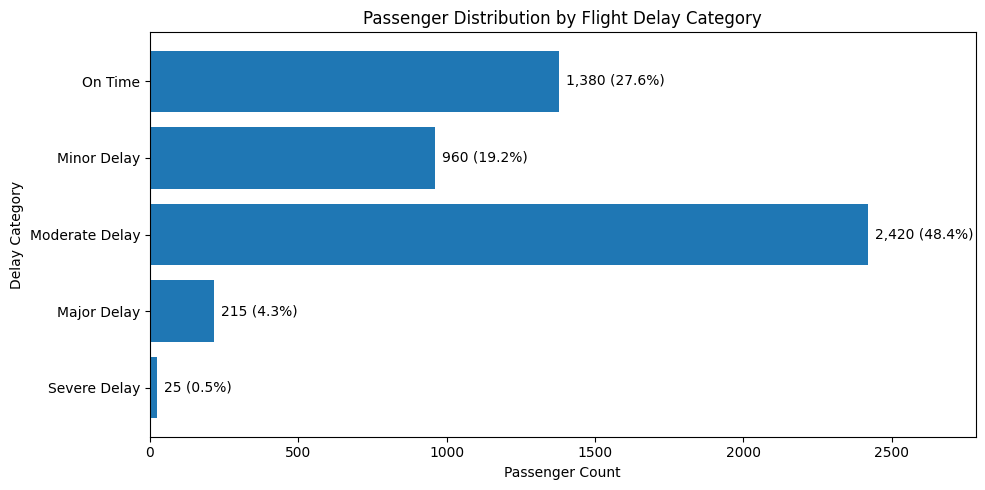

In [48]:
# Create delay categories

def classify_delay(delay):
    if delay <= 0:
        return "On Time"
    elif delay <= 15:
        return "Minor Delay"
    elif delay <= 60:
        return "Moderate Delay"
    elif delay <= 120:
        return "Major Delay"
    else:
        return "Severe Delay"


eda_df["delay_category"] = eda_df["delay"].apply(classify_delay)

# Verify
eda_df["delay_category"].value_counts()


# 2. Passenger Distribution by Delay Category
delay_order = [
    "On Time",
    "Minor Delay",
    "Moderate Delay",
    "Major Delay",
    "Severe Delay"
]

delay_distribution = (
    eda_df["delay_category"]
    .value_counts()
    .reindex(delay_order)
)

total_passengers = delay_distribution.sum()

percentages = (
    delay_distribution / total_passengers * 100
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    delay_distribution.index,
    delay_distribution.values
)

# Add count + percentage labels
labels = [
    f"{count:,} ({pct:.1f}%)"
    for count, pct in zip(
        delay_distribution.values,
        percentages.values
    )
]

ax.bar_label(
    bars,
    labels=labels,
    padding=5
)

ax.set_title("Passenger Distribution by Flight Delay Category")
ax.set_xlabel("Passenger Count")
ax.set_ylabel("Delay Category")

# Put On Time at the top
ax.invert_yaxis()

# Give labels some space
ax.set_xlim(
    0,
    delay_distribution.max() * 1.15
)

plt.tight_layout()
plt.show()

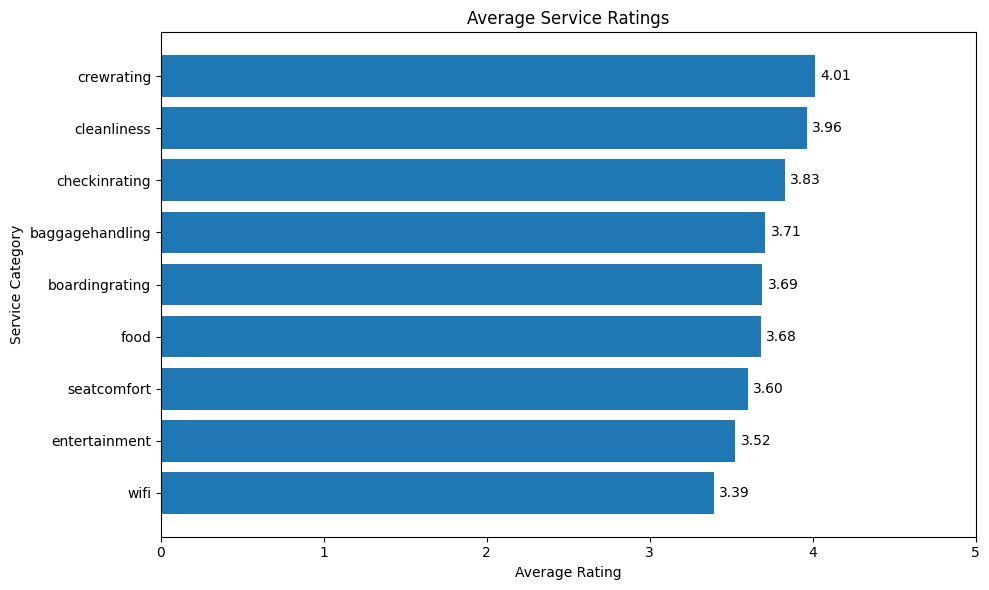

In [49]:
# 3. Service Rating Distributions

service_columns = [
    "wifi",
    "entertainment",
    "seatcomfort",
    "food",
    "boardingrating",
    "baggagehandling",
    "checkinrating",
    "cleanliness",
    "crewrating"
]

service_means = (
    eda_df[service_columns]
    .mean()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    service_means.index,
    service_means.values
)

ax.bar_label(
    bars,
    fmt="%.2f",
    padding=4
)

ax.set_title("Average Service Ratings")
ax.set_xlabel("Average Rating")
ax.set_ylabel("Service Category")
ax.set_xlim(0, 5)

plt.tight_layout()
plt.show()

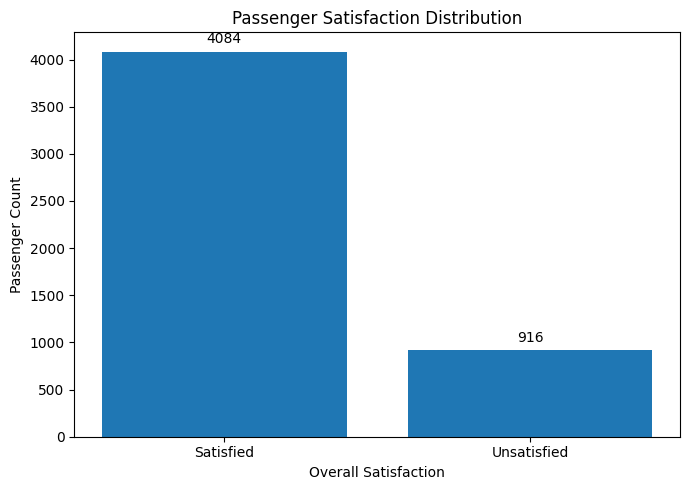

In [52]:
#4. Passenger Satisfaction Distribution

satisfaction_counts = (
    eda_df["overallsatisfaction"]
    .value_counts()
)

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    satisfaction_counts.index,
    satisfaction_counts.values
)

ax.bar_label(
    bars,
    fmt="%d",
    padding=4
)

ax.set_title("Passenger Satisfaction Distribution")
ax.set_xlabel("Overall Satisfaction")
ax.set_ylabel("Passenger Count")

plt.tight_layout()
plt.show()

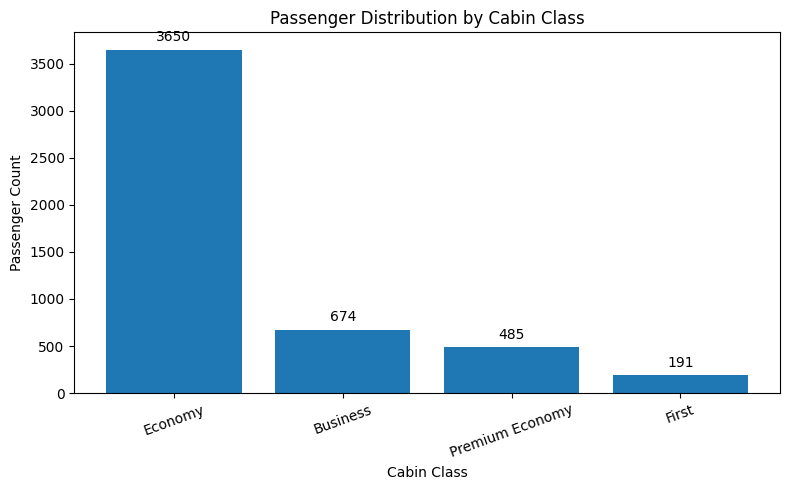

In [57]:
#5. Passenger Distribution by Cabin Class

cabin_counts = (
    eda_df["cabinclass"]
    .value_counts()
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    cabin_counts.index,
    cabin_counts.values
)

ax.bar_label(
    bars,
    fmt="%d",
    padding=4
)

ax.set_title("Passenger Distribution by Cabin Class")
ax.set_xlabel("Cabin Class")
ax.set_ylabel("Passenger Count")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

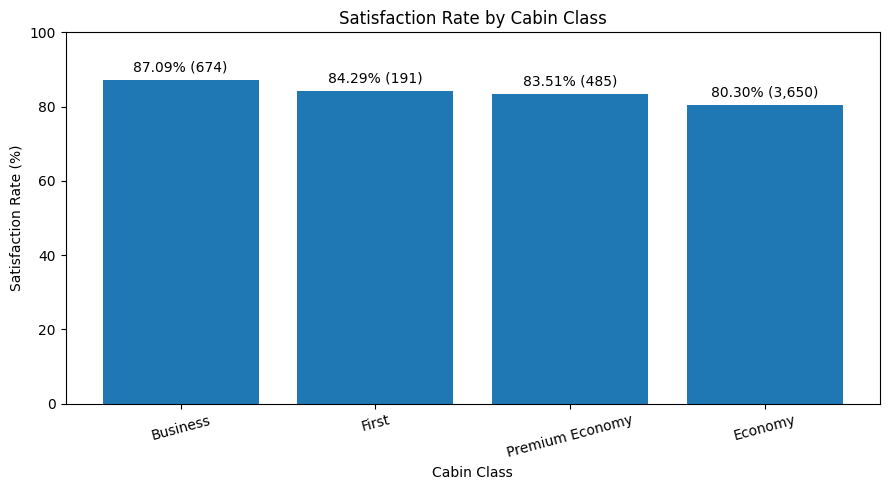

In [59]:
#6. Satisfaction by Cabin Class

cabin_satisfaction = (
    eda_df
    .groupby("cabinclass")
    .agg(
        passenger_count=("experiencekey", "count"),
        satisfaction_rate=(
            "overallsatisfaction",
            lambda x: (x == "Satisfied").mean() * 100
        ),
        average_nps=("nps", "mean")
    )
    .sort_values("satisfaction_rate", ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    cabin_satisfaction.index,
    cabin_satisfaction["satisfaction_rate"]
)

labels = [
    f"{rate:.2f}% ({count:,})"
    for rate, count in zip(
        cabin_satisfaction["satisfaction_rate"],
        cabin_satisfaction["passenger_count"]
    )
]

ax.bar_label(
    bars,
    labels=labels,
    padding=4
)

ax.set_title("Satisfaction Rate by Cabin Class")
ax.set_xlabel("Cabin Class")
ax.set_ylabel("Satisfaction Rate (%)")
ax.set_ylim(0, 100)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

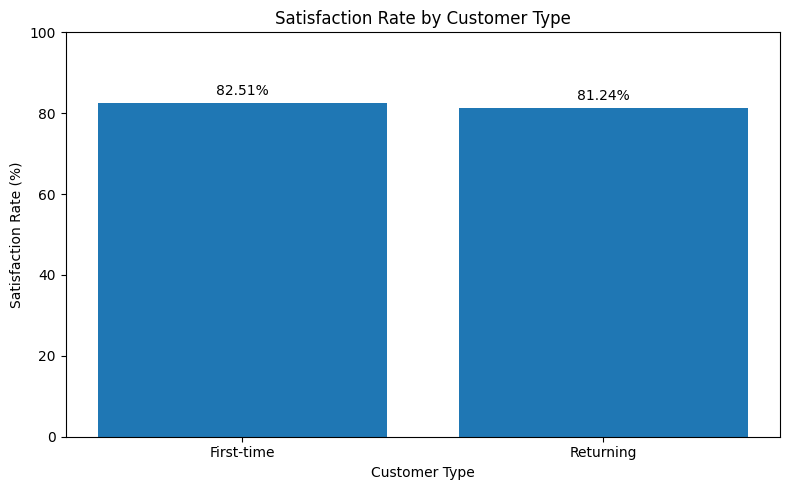

In [54]:
# 7. Satisfaction by Customer Type

customer_type_analysis = (
    eda_df
    .groupby("customertype")
    .agg(
        passenger_count=("experiencekey", "count"),
        satisfaction_rate=(
            "overallsatisfaction",
            lambda x: (x == "Satisfied").mean() * 100
        ),
        average_nps=("nps", "mean"),
        average_delay=("delay", "mean")
    )
    .sort_values("satisfaction_rate", ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    customer_type_analysis.index,
    customer_type_analysis["satisfaction_rate"]
)

labels = [
    f"{rate:.2f}%"
    for rate in customer_type_analysis["satisfaction_rate"]
]

ax.bar_label(
    bars,
    labels=labels,
    padding=4
)

ax.set_title("Satisfaction Rate by Customer Type")
ax.set_xlabel("Customer Type")
ax.set_ylabel("Satisfaction Rate (%)")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

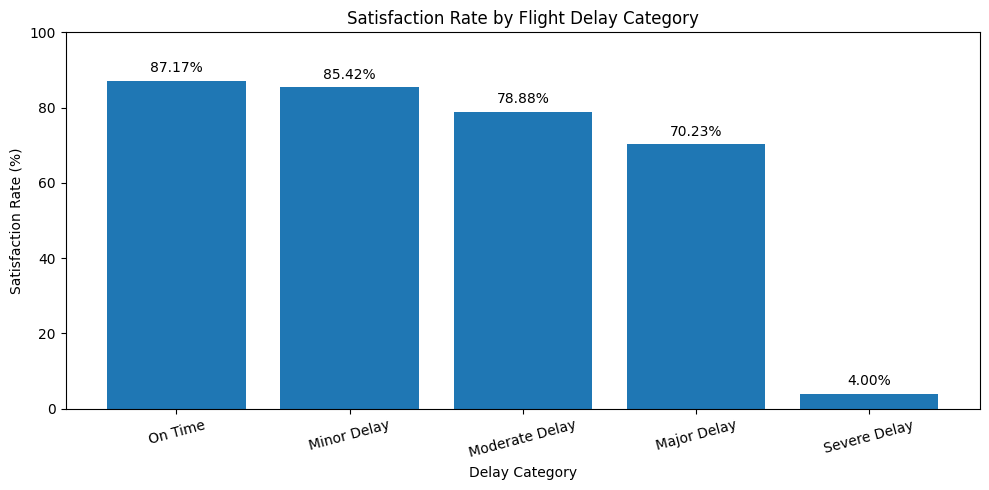

In [55]:
# 8. ⭐ Delay vs Satisfaction

def classify_delay(delay):
    if delay <= 0:
        return "On Time"
    elif delay <= 15:
        return "Minor Delay"
    elif delay <= 60:
        return "Moderate Delay"
    elif delay <= 120:
        return "Major Delay"
    else:
        return "Severe Delay"


eda_df["delay_category"] = eda_df["delay"].apply(classify_delay)

delay_order = [
    "On Time",
    "Minor Delay",
    "Moderate Delay",
    "Major Delay",
    "Severe Delay"
]

delay_analysis = (
    eda_df
    .groupby("delay_category")
    .agg(
        passenger_count=("experiencekey", "count"),
        satisfaction_rate=(
            "overallsatisfaction",
            lambda x: (x == "Satisfied").mean() * 100
        ),
        complaint_rate=(
            "complainttype",
            lambda x: x.notna().mean() * 100
        ),
        average_nps=("nps", "mean")
    )
    .reindex(delay_order)
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    delay_analysis.index,
    delay_analysis["satisfaction_rate"]
)

labels = [
    f"{rate:.2f}%"
    for rate in delay_analysis["satisfaction_rate"]
]

ax.bar_label(
    bars,
    labels=labels,
    padding=4
)

ax.set_title("Satisfaction Rate by Flight Delay Category")
ax.set_xlabel("Delay Category")
ax.set_ylabel("Satisfaction Rate (%)")
ax.set_ylim(0, 100)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

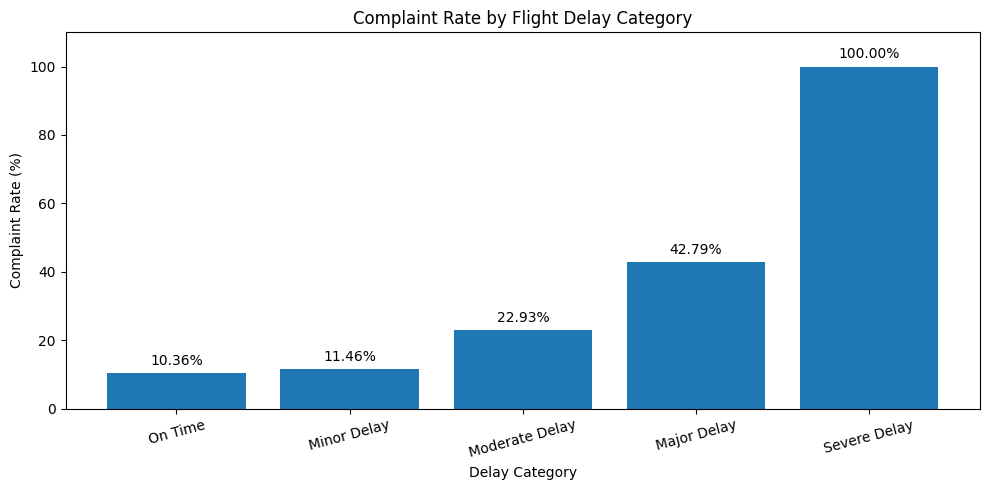

In [56]:
# 9. ⭐ Bonus: Complaints by Delay Category

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    delay_analysis.index,
    delay_analysis["complaint_rate"]
)

labels = [
    f"{rate:.2f}%"
    for rate in delay_analysis["complaint_rate"]
]

ax.bar_label(
    bars,
    labels=labels,
    padding=4
)

ax.set_title("Complaint Rate by Flight Delay Category")
ax.set_xlabel("Delay Category")
ax.set_ylabel("Complaint Rate (%)")
ax.set_ylim(0, 110)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Service Quality Analysis

Compare average service ratings between satisfied and unsatisfied passengers
to identify service dimensions associated with differences in passenger experience.

### 1. Service Rating vs Satisfaction

In [65]:
service_columns = [
    "wifi",
    "entertainment",
    "seatcomfort",
    "food",
    "boardingrating",
    "baggagehandling",
    "checkinrating",
    "cleanliness",
    "crewrating"
]

service_satisfaction = (
    eda_df
    .groupby("overallsatisfaction")[service_columns]
    .mean()
    .round(2)
    .T
)

service_satisfaction

overallsatisfaction,Satisfied,Unsatisfied
wifi,3.52,2.80
entertainment,3.65,2.96
seatcomfort,3.72,3.05
food,3.80,3.13
boardingrating,3.82,3.12
baggagehandling,3.83,3.17
checkinrating,3.96,3.26
cleanliness,4.08,3.44
crewrating,4.13,3.52


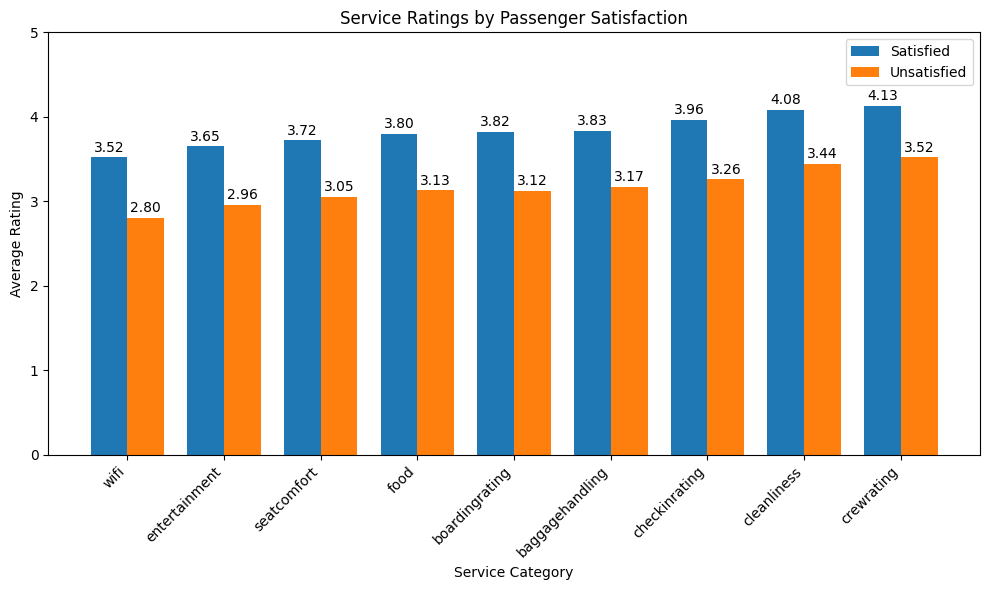

In [66]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(service_satisfaction.index))
width = 0.38

satisfied = service_satisfaction["Satisfied"]
unsatisfied = service_satisfaction["Unsatisfied"]

bars1 = ax.bar(
    x - width/2,
    satisfied,
    width,
    label="Satisfied"
)

bars2 = ax.bar(
    x + width/2,
    unsatisfied,
    width,
    label="Unsatisfied"
)

ax.bar_label(bars1, fmt="%.2f", padding=2)
ax.bar_label(bars2, fmt="%.2f", padding=2)

ax.set_title("Service Ratings by Passenger Satisfaction")
ax.set_xlabel("Service Category")
ax.set_ylabel("Average Rating")
ax.set_xticks(x)
ax.set_xticklabels(service_satisfaction.index, rotation=45, ha="right")
ax.set_ylim(0, 5)

ax.legend()

plt.tight_layout()
plt.show()

### 2. Which Service Areas Have the Biggest Satisfaction Gap?

In [ ]:
service_satisfaction["rating_gap"] = (
    service_satisfaction["Satisfied"]
    - service_satisfaction["Unsatisfied"]
)

service_gap = (
    service_satisfaction[["rating_gap"]]
    .sort_values("rating_gap", ascending=False)
)

service_gap

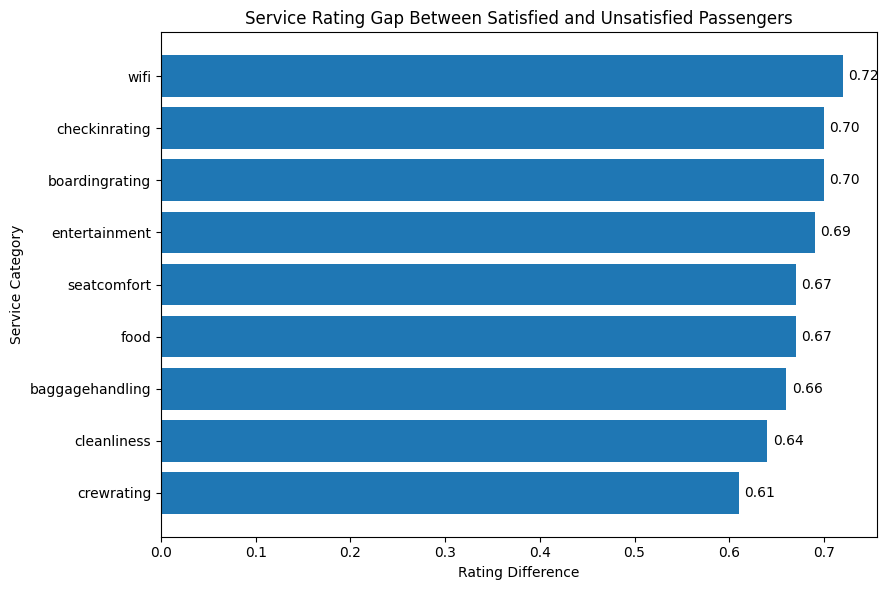

In [68]:
fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(
    service_gap.index,
    service_gap["rating_gap"]
)

ax.bar_label(
    bars,
    fmt="%.2f",
    padding=4
)

ax.set_title("Service Rating Gap Between Satisfied and Unsatisfied Passengers")
ax.set_xlabel("Rating Difference")
ax.set_ylabel("Service Category")

ax.invert_yaxis()

plt.tight_layout()
plt.show()

## NPS Distribution

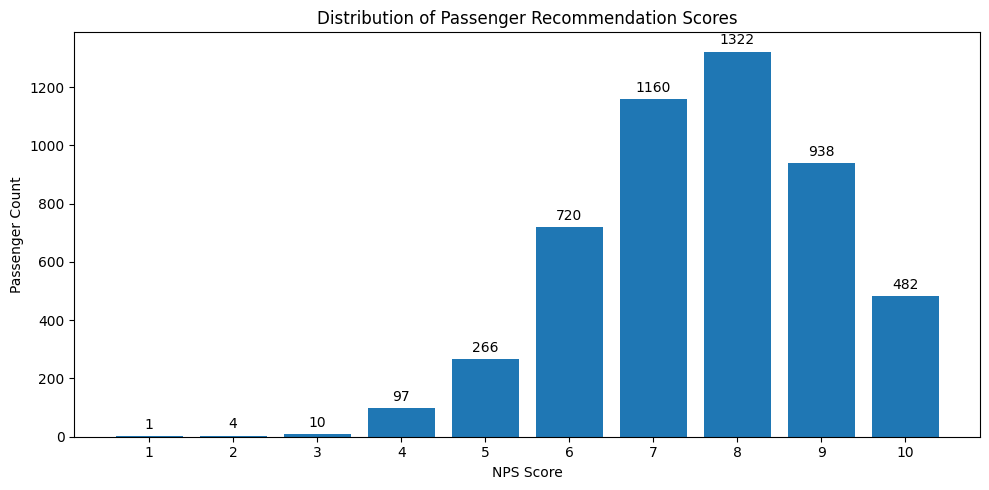

In [69]:
nps_distribution = (
    eda_df["nps"]
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    nps_distribution.index.astype(str),
    nps_distribution.values
)

ax.bar_label(
    bars,
    fmt="%d",
    padding=3
)

ax.set_title("Distribution of Passenger Recommendation Scores")
ax.set_xlabel("NPS Score")
ax.set_ylabel("Passenger Count")

plt.tight_layout()
plt.show()

In [70]:
# Create promoter/passive/detractor groups.

def classify_nps(score):
    if score >= 9:
        return "Promoter"
    elif score >= 7:
        return "Passive"
    else:
        return "Detractor"


eda_df["nps_segment"] = eda_df["nps"].apply(classify_nps)

nps_segments = (
    eda_df["nps_segment"]
    .value_counts()
    .reindex(["Promoter", "Passive", "Detractor"])
)

nps_percentages = (
    nps_segments / len(eda_df) * 100
)

nps_segments

nps_segment
Promoter     1420
Passive      2482
Detractor    1098
Name: count, dtype: int64

In [73]:
promoter_pct = nps_percentages["Promoter"]
detractor_pct = nps_percentages["Detractor"]

standard_nps = promoter_pct - detractor_pct

print(f"Promoters: {promoter_pct:.2f}%")
print(f"Passives: {nps_percentages['Passive']:.2f}%")
print(f"Detractors: {detractor_pct:.2f}%")
print(f"Standard NPS: {standard_nps:.2f}")

Promoters: 28.40%
Passives: 49.64%
Detractors: 21.96%
Standard NPS: 6.44


# Delay vs NPS
We already established Delay -> Satisfaction. Now we're checking how Delay impacts Recommendation (NPS)

In [74]:
delay_nps = (
    eda_df
    .groupby("delay_category")
    .agg(
        passenger_count=("experiencekey", "count"),
        average_nps=("nps", "mean"),
        satisfaction_rate=(
            "overallsatisfaction",
            lambda x: (x == "Satisfied").mean() * 100
        ),
        complaint_rate=(
            "complainttype",
            lambda x: x.notna().mean() * 100
        )
    )
    .reindex(delay_order)
)

delay_nps

,passenger_count,average_nps,satisfaction_rate,complaint_rate
delay_category,,,,
On Time,1380,7.963768,87.173913,10.362319
Minor Delay,960,7.728125,85.416667,11.458333
Moderate Delay,2420,7.455372,78.884298,22.933884
Major Delay,215,6.925581,70.232558,42.790698
Severe Delay,25,3.800000,4.000000,100.000000


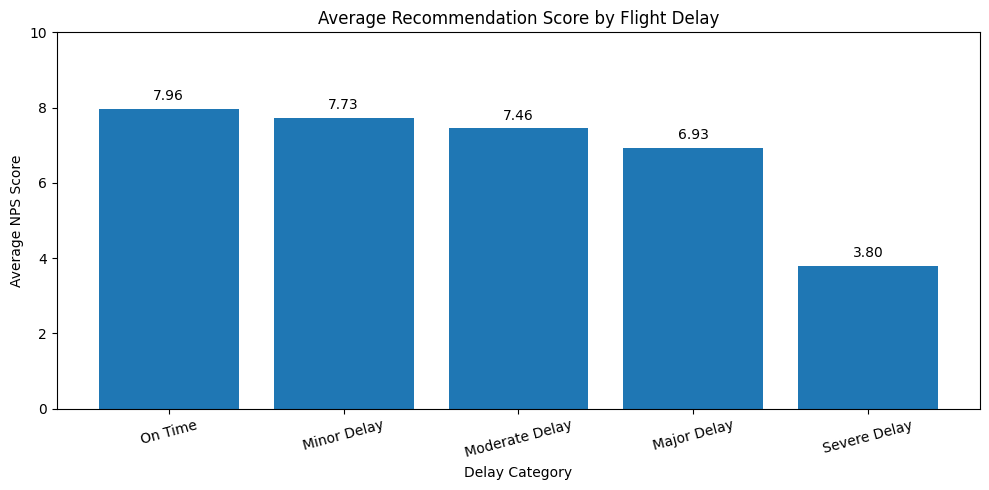

In [75]:
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    delay_nps.index,
    delay_nps["average_nps"]
)

ax.bar_label(
    bars,
    fmt="%.2f",
    padding=4
)

ax.set_title("Average Recommendation Score by Flight Delay")
ax.set_xlabel("Delay Category")
ax.set_ylabel("Average NPS Score")
ax.set_ylim(0, 10)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

# Customer Segmentation Analysis

In [77]:
# Customer type

customer_analysis = (
    eda_df
    .groupby("customertype")
    .agg(
        passengers=("experiencekey", "count"),
        satisfaction_rate=(
            "overallsatisfaction",
            lambda x: (x == "Satisfied").mean() * 100
        ),
        average_nps=("nps", "mean"),
        average_delay=("delay", "mean"),
        complaint_rate=(
            "complainttype",
            lambda x: x.notna().mean() * 100
        )
    )
)

customer_analysis

,passengers,satisfaction_rate,average_nps,average_delay,complaint_rate
customertype,,,,,
First-time,1738,82.508631,7.601841,19.453395,18.009206
Returning,3262,81.238504,7.609749,19.363887,18.761496


# Loyalty Tier Analysis

In [78]:
loyalty_analysis = (
    eda_df
    .groupby("loyaltytier")
    .agg(
        passengers=("experiencekey", "count"),
        satisfaction_rate=(
            "overallsatisfaction",
            lambda x: (x == "Satisfied").mean() * 100
        ),
        average_nps=("nps", "mean"),
        complaint_rate=(
            "complainttype",
            lambda x: x.notna().mean() * 100
        )
    )
    .sort_values("satisfaction_rate", ascending=False)
)

loyalty_analysis

,passengers,satisfaction_rate,average_nps,complaint_rate
loyaltytier,,,,
Gold,1011,82.393670,7.651830,17.804154
Silver,1135,81.585903,7.602643,19.118943
Platinum,455,81.538462,7.512088,18.021978
None,2399,81.450604,7.608170,18.591080


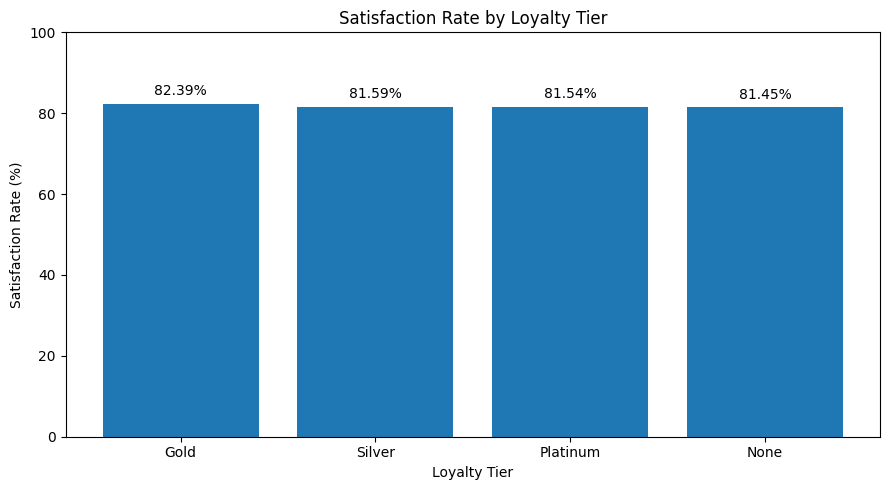

In [79]:
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    loyalty_analysis.index.astype(str),
    loyalty_analysis["satisfaction_rate"]
)

ax.bar_label(
    bars,
    fmt="%.2f%%",
    padding=4
)

ax.set_title("Satisfaction Rate by Loyalty Tier")
ax.set_xlabel("Loyalty Tier")
ax.set_ylabel("Satisfaction Rate (%)")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

# Travel Type Analysis

In [80]:
travel_analysis = (
    eda_df
    .groupby("traveltype")
    .agg(
        passengers=("experiencekey", "count"),
        satisfaction_rate=(
            "overallsatisfaction",
            lambda x: (x == "Satisfied").mean() * 100
        ),
        average_nps=("nps", "mean"),
        average_delay=("delay", "mean"),
        complaint_rate=(
            "complainttype",
            lambda x: x.notna().mean() * 100
        )
    )
    .sort_values("satisfaction_rate", ascending=False)
)

travel_analysis

,passengers,satisfaction_rate,average_nps,average_delay,complaint_rate
traveltype,,,,,
Leisure,2999,81.927309,7.607202,19.419140,18.106035
Business,2001,81.309345,7.606697,19.358821,19.090455


# Booking Channel Analysis
Useful from commercial perspective - this lets us answer Are some booking channels associated with different customer experience or revenue characteristics?

In [81]:
booking_analysis = (
    eda_df
    .groupby("bookingchannel")
    .agg(
        passengers=("experiencekey", "count"),
        satisfaction_rate=(
            "overallsatisfaction",
            lambda x: (x == "Satisfied").mean() * 100
        ),
        average_nps=("nps", "mean"),
        average_fare=("fare", "mean"),
        complaint_rate=(
            "complainttype",
            lambda x: x.notna().mean() * 100
        )
    )
    .sort_values("passengers", ascending=False)
)

booking_analysis

,passengers,satisfaction_rate,average_nps,average_fare,complaint_rate
bookingchannel,,,,,
Corporate,1021,81.292850,7.617042,9219.578844,19.392752
Mobile App,1009,81.169475,7.597621,9537.799802,19.127849
Ota,1002,81.137725,7.571856,9562.425150,19.061876
Website,992,83.266129,7.657258,9767.489919,16.733871
Travel Agent,976,81.557377,7.591189,9680.676230,18.135246


# 10. Route Type Analysis

In [82]:
route_type_analysis = (
    eda_df
    .groupby("routetype")
    .agg(
        passengers=("experiencekey", "count"),
        satisfaction_rate=(
            "overallsatisfaction",
            lambda x: (x == "Satisfied").mean() * 100
        ),
        average_nps=("nps", "mean"),
        average_delay=("delay", "mean"),
        average_fare=("fare", "mean"),
        total_revenue=(
            "fare",
            "sum"
        )
    )
)

route_type_analysis

,passengers,satisfaction_rate,average_nps,average_delay,average_fare,total_revenue
routetype,,,,,,
Domestic,3500,81.514286,7.590857,18.835714,8018.937143,28066280.0
International,1500,82.066667,7.644667,20.700000,13126.526667,19689790.0


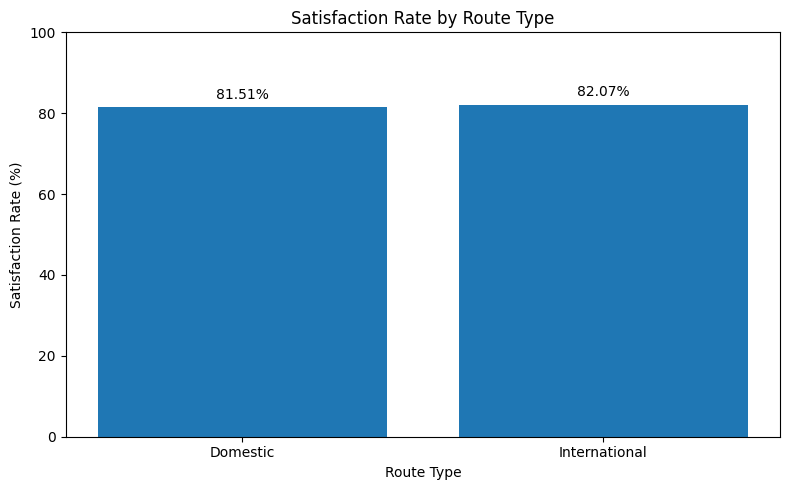

In [83]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    route_type_analysis.index,
    route_type_analysis["satisfaction_rate"]
)

ax.bar_label(
    bars,
    fmt="%.2f%%",
    padding=4
)

ax.set_title("Satisfaction Rate by Route Type")
ax.set_xlabel("Route Type")
ax.set_ylabel("Satisfaction Rate (%)")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

# 11. Revenue Analysis

In [84]:
eda_df["total_revenue"] = (
    eda_df["fare"]
    + eda_df["ancillaryrevenue"]
)

In [87]:
revenue_summary = eda_df[
    ["fare", "ancillaryrevenue", "total_revenue"]
].describe().T

revenue_summary # This is per passenger summary

,count,mean,std,min,25%,50%,75%,max
fare,5000.0,9551.2140,7756.927800,3500.0,5267.5,6690.0,10670.00,92390.0
ancillaryrevenue,5000.0,1564.2448,887.320660,0.0,903.0,1485.0,2168.25,5001.0
total_revenue,5000.0,11115.4588,8165.793197,3530.0,6462.0,8055.5,12791.50,96380.0


In [90]:
# Revenue by Cabin Class

cabin_revenue = (
    eda_df
    .groupby("cabinclass")
    .agg(
        passengers=("experiencekey", "count"),
        total_revenue=("total_revenue", "sum"),
        average_revenue=("total_revenue", "mean"),
        satisfaction_rate=(
            "overallsatisfaction",
            lambda x: (x == "Satisfied").mean() * 100
        )
    )
    .sort_values("total_revenue", ascending=False)
)

cabin_revenue

,passengers,total_revenue,average_revenue,satisfaction_rate
cabinclass,,,,
Economy,3650,28250021.0,7739.731781,80.301370
Business,674,14842760.0,22021.899110,87.091988
First,191,6327111.0,33126.235602,84.293194
Premium Economy,485,6157402.0,12695.674227,83.505155


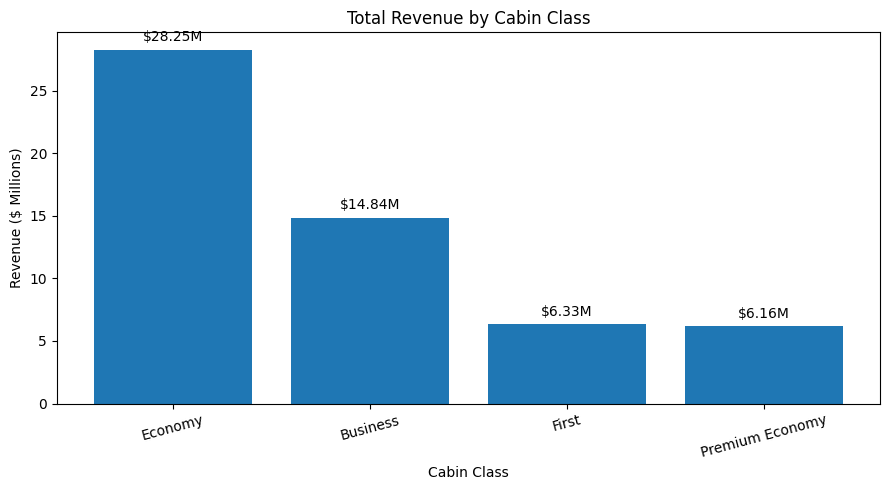

In [89]:
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    cabin_revenue.index,
    cabin_revenue["total_revenue"] / 1_000_000
)

ax.bar_label(
    bars,
    labels=[
        f"${v:.2f}M"
        for v in cabin_revenue["total_revenue"] / 1_000_000
    ],
    padding=4
)

ax.set_title("Total Revenue by Cabin Class")
ax.set_xlabel("Cabin Class")
ax.set_ylabel("Revenue ($ Millions)")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

# Revenue vs Satisfaction

In [91]:
revenue_satisfaction = (
    eda_df
    .groupby("overallsatisfaction")
    .agg(
        passengers=("experiencekey", "count"),
        average_revenue=("total_revenue", "mean"),
        total_revenue=("total_revenue", "sum"),
        average_fare=("fare", "mean")
    )
)

revenue_satisfaction

,passengers,average_revenue,total_revenue,average_fare
overallsatisfaction,,,,
Satisfied,4084,11284.477228,46085805.0,9705.945152
Unsatisfied,916,10361.887555,9491489.0,8861.342795


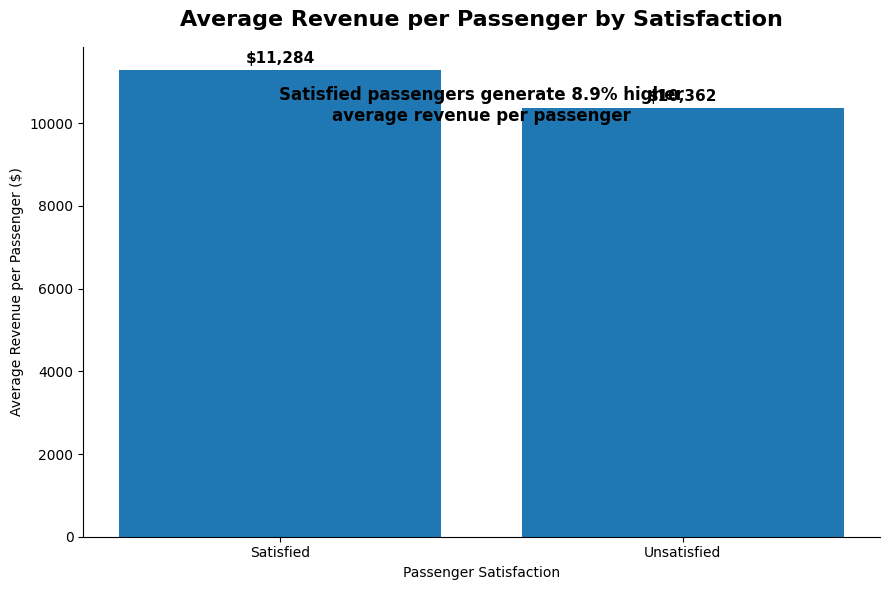

In [92]:
import matplotlib.pyplot as plt

# Calculate average revenue per passenger by satisfaction
revenue_by_satisfaction = (
    eda_df
    .groupby("overallsatisfaction")
    .agg(
        passengers=("experiencekey", "count"),
        average_revenue=("total_revenue", "mean")
    )
    .reindex(["Satisfied", "Unsatisfied"])
)

# Calculate revenue premium
satisfied_revenue = revenue_by_satisfaction.loc["Satisfied", "average_revenue"]
unsatisfied_revenue = revenue_by_satisfaction.loc["Unsatisfied", "average_revenue"]

revenue_premium = (
    (satisfied_revenue / unsatisfied_revenue) - 1
) * 100

# Create chart
fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    revenue_by_satisfaction.index,
    revenue_by_satisfaction["average_revenue"]
)

# Add data labels
for bar, value in zip(bars, revenue_by_satisfaction["average_revenue"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f"${value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Business insight annotation
ax.text(
    0.5,
    0.88,
    f"Satisfied passengers generate {revenue_premium:.1f}% higher\n"
    f"average revenue per passenger",
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold"
)

# Titles and labels
ax.set_title(
    "Average Revenue per Passenger by Satisfaction",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_ylabel("Average Revenue per Passenger ($)")
ax.set_xlabel("Passenger Satisfaction")

# Clean presentation
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

- Business Insight:
Satisfied passengers generate approximately 8.9% higher average revenue
per passenger than unsatisfied passengers, indicating a positive association
between passenger satisfaction and passenger value.

This suggests that improving customer experience may have commercial benefits,
although the analysis shows association rather than causation.

# ⭐ Correlation Analysis

In [93]:
correlation_columns = [
    "age",
    "duration",
    "distance",
    "delay",
    "checkinrating",
    "boardingrating",
    "crewrating",
    "seatcomfort",
    "wifi",
    "entertainment",
    "food",
    "cleanliness",
    "baggagehandling",
    "nps",
    "fare",
    "ancillaryrevenue"
]

correlation_matrix = (
    eda_df[correlation_columns]
    .corr()
)

correlation_matrix.round(2)

,age,duration,distance,delay,checkinrating,boardingrating,crewrating,seatcomfort,wifi,entertainment,food,cleanliness,baggagehandling,nps,fare,ancillaryrevenue
age,1.00,0.02,0.02,-0.02,-0.02,0.00,0.03,0.01,-0.00,-0.01,-0.00,0.01,0.01,0.00,0.02,0.00
duration,0.02,1.00,0.90,0.04,-0.04,-0.03,-0.03,-0.03,-0.01,-0.01,0.01,-0.02,-0.01,0.00,0.45,-0.02
distance,0.02,0.90,1.00,0.05,-0.04,-0.03,-0.03,-0.03,0.00,-0.00,0.02,-0.02,-0.01,0.00,0.51,-0.02
delay,-0.02,0.04,0.05,1.00,-0.01,-0.01,-0.01,0.01,-0.04,-0.01,-0.02,0.00,-0.01,-0.27,0.00,-0.00
checkinrating,-0.02,-0.04,-0.04,-0.01,1.00,0.40,0.42,0.41,0.36,0.37,0.40,0.42,0.40,0.31,-0.01,0.00
boardingrating,0.00,-0.03,-0.03,-0.01,0.40,1.00,0.39,0.38,0.33,0.37,0.35,0.40,0.37,0.29,-0.01,-0.00
crewrating,0.03,-0.03,-0.03,-0.01,0.42,0.39,1.00,0.39,0.34,0.38,0.39,0.41,0.40,0.33,-0.00,0.01
seatcomfort,0.01,-0.03,-0.03,0.01,0.41,0.38,0.39,1.00,0.31,0.33,0.34,0.37,0.35,0.29,-0.01,0.01
wifi,-0.00,-0.01,0.00,-0.04,0.36,0.33,0.34,0.31,1.00,0.30,0.31,0.33,0.32,0.30,0.02,0.01
entertainment,-0.01,-0.01,-0.00,-0.01,0.37,0.37,0.38,0.33,0.30,1.00,0.35,0.37,0.36,0.30,0.00,0.02


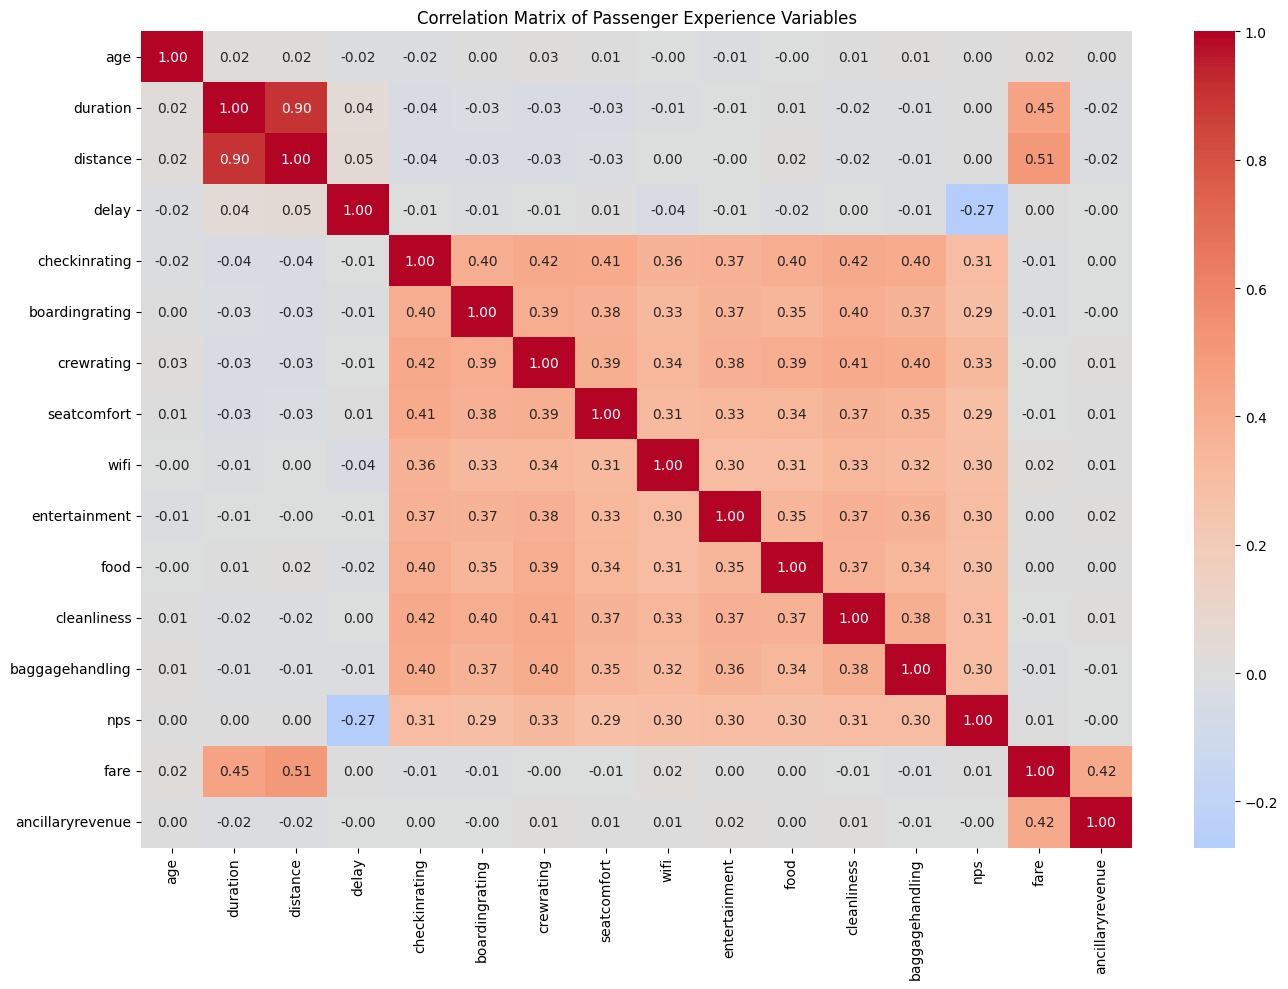

In [94]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Passenger Experience Variables")

plt.tight_layout()
plt.show()

# Correlation with NPS

In [95]:
nps_correlations = (
    correlation_matrix["nps"]
    .drop("nps")
    .sort_values()
)

nps_correlations

delay              -0.272068
ancillaryrevenue   -0.003785
distance            0.001564
age                 0.003518
duration            0.004729
fare                0.008919
seatcomfort         0.288760
boardingrating      0.291419
wifi                0.295435
food                0.297545
entertainment       0.302289
baggagehandling     0.302526
cleanliness         0.305606
checkinrating       0.313173
crewrating          0.328243
Name: nps, dtype: float64

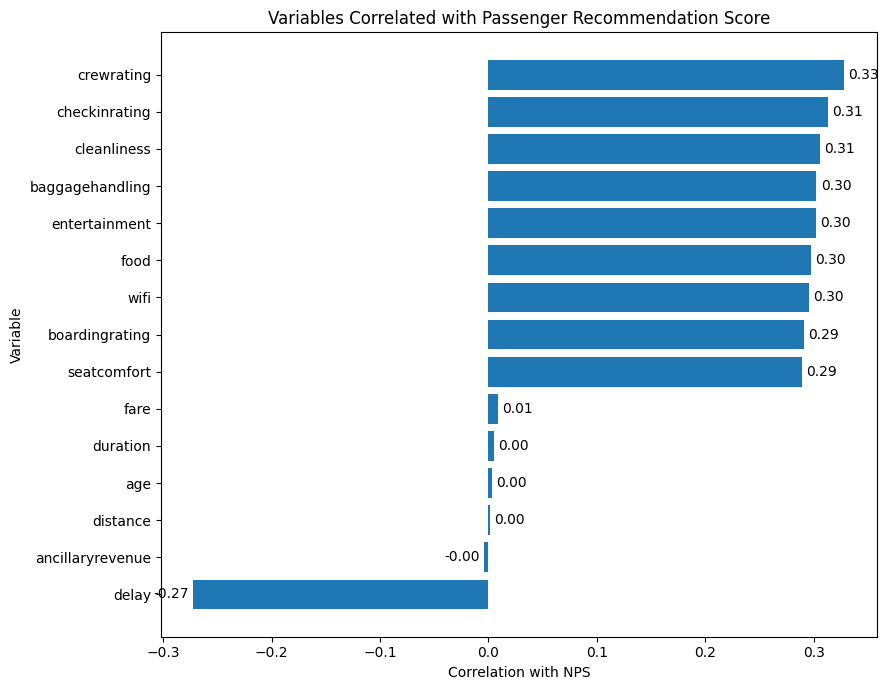

In [96]:
fig, ax = plt.subplots(figsize=(9, 7))

bars = ax.barh(
    nps_correlations.index,
    nps_correlations.values
)

ax.bar_label(
    bars,
    fmt="%.2f",
    padding=3
)

ax.set_title("Variables Correlated with Passenger Recommendation Score")
ax.set_xlabel("Correlation with NPS")
ax.set_ylabel("Variable")

plt.tight_layout()
plt.show()

# Route-Level EDA

In [101]:
route_analysis = (
    eda_df
    .groupby("route")
    .agg(
        passengers=("experiencekey", "count"),
        satisfaction_rate=(
            "overallsatisfaction",
            lambda x: (x == "Satisfied").mean() * 100
        ),
        average_nps=("nps", "mean"),
        average_delay=("delay", "mean"),
        complaint_rate=(
            "complainttype",
            lambda x: x.notna().mean() * 100
        ),
        total_revenue=("total_revenue", "sum")
    )
    .sort_values("satisfaction_rate")
)

route_analysis.head(10)

,passengers,satisfaction_rate,average_nps,average_delay,complaint_rate,total_revenue
route,,,,,,
DEL-BLR,350,76.285714,7.505714,22.428571,25.142857,3312249.0
BOM-DXB,125,77.600000,7.560000,36.440000,19.200000,1477946.0
DEL-SIN,120,78.333333,7.566667,26.250000,24.166667,2116422.0
CCU-BKK,135,78.518519,7.577778,21.185185,21.481481,1494108.0
LKO-BLR,330,80.000000,7.563636,19.181818,19.393939,3197881.0
HYD-DXB,105,80.000000,7.609524,22.285714,20.000000,1467547.0
DEL-BOM,350,80.285714,7.637143,19.328571,17.142857,3363257.0
GOI-BOM,400,80.750000,7.642500,18.975000,19.000000,3670369.0
DEL-LHR,75,81.333333,7.800000,25.933333,21.333333,1859422.0


In [103]:
# Top 10 routes with highest satisfaction

route_analysis.sort_values(
    "satisfaction_rate",
    ascending=False
).head(10)

,passengers,satisfaction_rate,average_nps,average_delay,complaint_rate,total_revenue
route,,,,,,
DEL-KTM,85,88.235294,7.717647,10.941176,10.588235,651981.0
BLR-SIN,140,86.428571,7.707143,16.357143,16.428571,2057257.0
PNQ-DEL,290,84.482759,7.803448,17.879310,16.896552,2851756.0
IXC-HYD,340,84.411765,7.511765,19.705882,17.058824,3526770.0
DEL-CMB,100,84.000000,7.620000,18.850000,18.000000,1350640.0
MAA-SIN,120,83.333333,7.658333,15.958333,17.500000,1627876.0
AMD-BLR,400,83.250000,7.537500,14.600000,14.250000,3901410.0
DEL-DXB,130,83.076923,7.807692,12.000000,17.692308,1590973.0
BOM-LHR,110,82.727273,7.445455,21.727273,19.090909,3135045.0


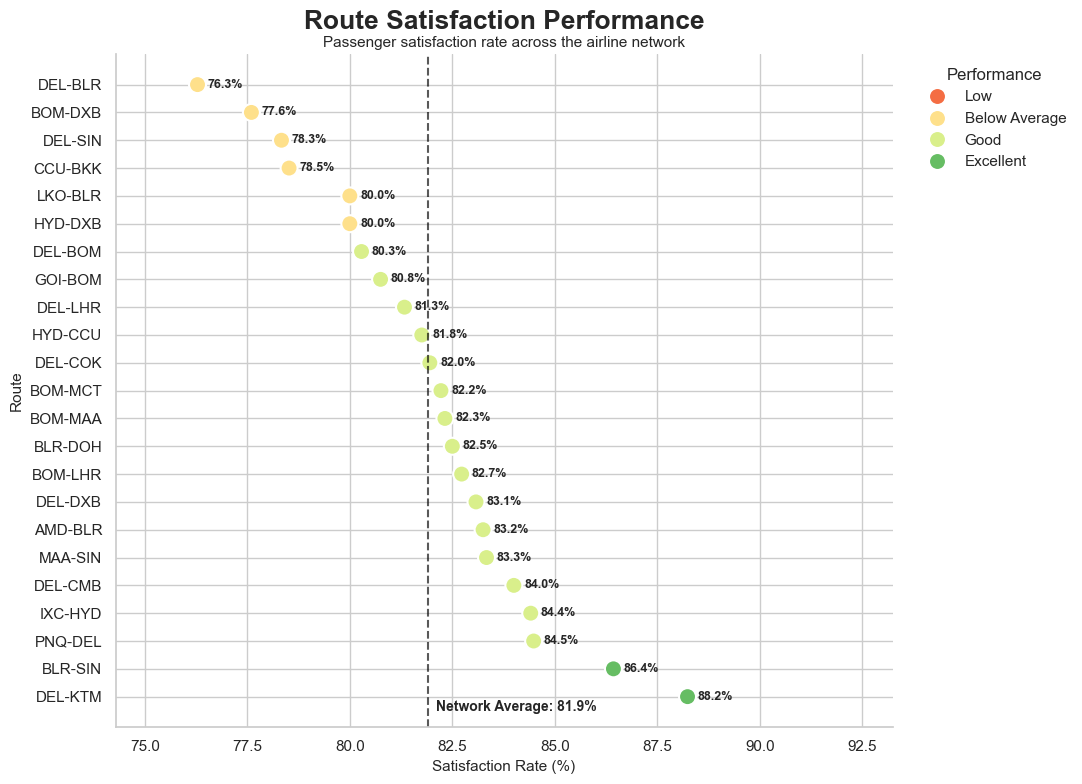

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare route satisfaction data
satisfaction_plot = (
    route_analysis
    .reset_index()[["route", "satisfaction_rate"]]
    .sort_values("satisfaction_rate", ascending=True)
)

# Create satisfaction bands for color
satisfaction_plot["performance"] = pd.cut(
    satisfaction_plot["satisfaction_rate"],
    bins=[0, 75, 80, 85, 100],
    labels=[
        "Low",
        "Below Average",
        "Good",
        "Excellent"
    ]
)

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(11, 8))

# Color-coded dots
sns.scatterplot(
    data=satisfaction_plot,
    x="satisfaction_rate",
    y="route",
    hue="performance",
    palette="RdYlGn",
    s=150,
    edgecolor="white",
    linewidth=1.5,
    ax=ax
)

# Add percentage labels
for _, row in satisfaction_plot.iterrows():
    ax.text(
        row["satisfaction_rate"] + 0.25,
        row["route"],
        f"{row['satisfaction_rate']:.1f}%",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

# Overall network average
avg_satisfaction = satisfaction_plot["satisfaction_rate"].mean()

ax.axvline(
    avg_satisfaction,
    linestyle="--",
    linewidth=1.5,
    color="black",
    alpha=0.65
)

ax.text(
    avg_satisfaction + 0.2,
    len(satisfaction_plot) - 0.5,
    f"Network Average: {avg_satisfaction:.1f}%",
    fontsize=10,
    fontweight="bold"
)

# Titles
ax.set_title(
    "Route Satisfaction Performance",
    fontsize=19,
    fontweight="bold",
    pad=18
)

ax.text(
    0.5,
    1.01,
    "Passenger satisfaction rate across the airline network",
    transform=ax.transAxes,
    ha="center",
    fontsize=11
)

ax.set_xlabel(
    "Satisfaction Rate (%)",
    fontsize=11
)

ax.set_ylabel(
    "Route",
    fontsize=11
)

# Give labels room
ax.set_xlim(
    satisfaction_plot["satisfaction_rate"].min() - 2,
    satisfaction_plot["satisfaction_rate"].max() + 5
)

# Clean presentation
sns.despine()

# Put legend outside the plot
ax.legend(
    title="Performance",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()
plt.show()

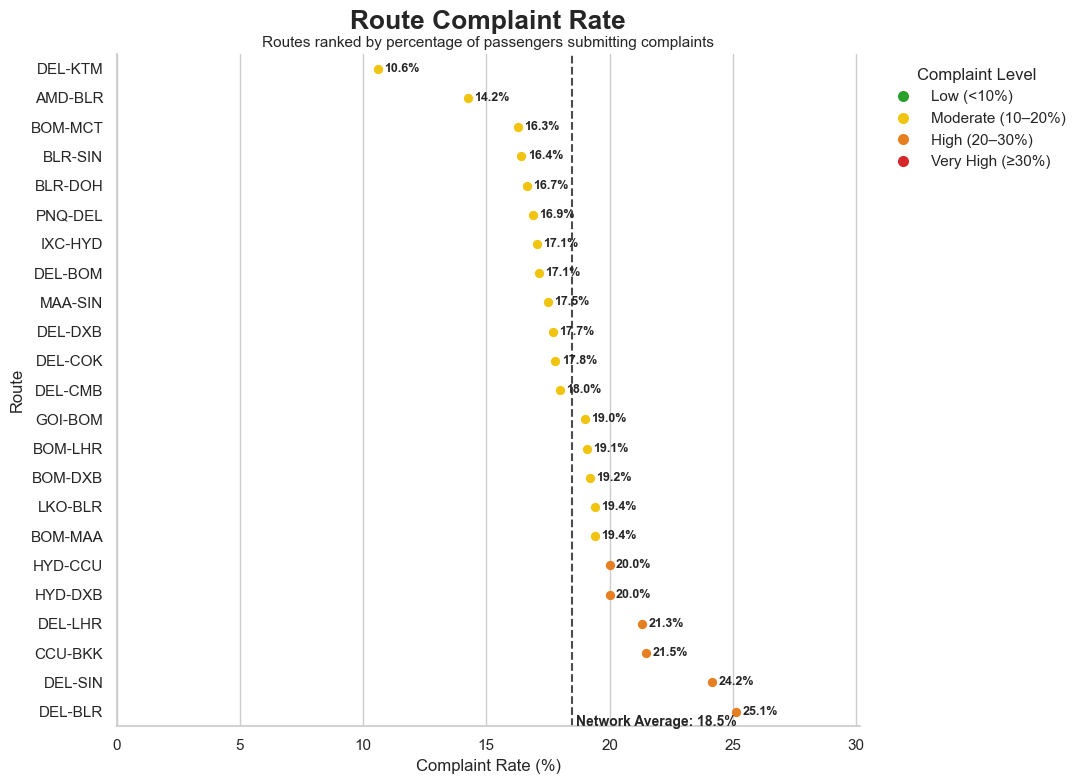

In [123]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare complaint data sorted in ASCENDING order
complaint_plot = (
    route_analysis.reset_index()[["route", "complaint_rate"]]
    .sort_values("complaint_rate", ascending=True)  # <-- Changed to True
    .reset_index(drop=True)
)


# 2. Classify complaint levels
def classify_complaint(rate):
    if rate < 10:
        return "Low"
    elif rate < 20:
        return "Moderate"
    elif rate < 30:
        return "High"
    return "Very High"


complaint_plot["complaint_level"] = complaint_plot["complaint_rate"].apply(
    classify_complaint
)

# Fixed colours
colors = {
    "Low": "#2ca02c",
    "Moderate": "#f1c40f",
    "High": "#e67e22",
    "Very High": "#d62728",
}

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 8))

# 3. Plot each complaint category
for level in ["Low", "Moderate", "High", "Very High"]:
    subset = complaint_plot[complaint_plot["complaint_level"] == level]

    if not subset.empty:
        sns.pointplot(
            data=subset,
            x="complaint_rate",
            y="route",
            order=complaint_plot["route"],  # Ensures strict sort order on y-axis
            color=colors[level],
            markers="o",
            linestyles="",
            scale=0.9,
            ax=ax,
        )

# 4. Add value labels
for _, row in complaint_plot.iterrows():
    ax.text(
        row["complaint_rate"] + 0.25,
        row["route"],
        f"{row['complaint_rate']:.1f}%",
        va="center",
        fontsize=9,
        fontweight="bold",
    )

# 5. Network average line & label
avg_complaint = complaint_plot["complaint_rate"].mean()

ax.axvline(
    avg_complaint, linestyle="--", linewidth=1.5, color="black", alpha=0.7
)

ax.text(
    avg_complaint + 0.2,
    len(complaint_plot) - 0.5,
    f"Network Average: {avg_complaint:.1f}%",
    fontsize=10,
    fontweight="bold",
)

# 6. Titles & Labels
ax.set_title("Route Complaint Rate", fontsize=19, fontweight="bold", pad=18)
ax.text(
    0.5,
    1.01,
    "Routes ranked by percentage of passengers submitting complaints",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
)

ax.set_xlabel("Complaint Rate (%)")
ax.set_ylabel("Route")
ax.set_xlim(0, complaint_plot["complaint_rate"].max() + 5)

# 7. Legend
legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=colors["Low"],
        markersize=9,
        label="Low (<10%)",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=colors["Moderate"],
        markersize=9,
        label="Moderate (10–20%)",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=colors["High"],
        markersize=9,
        label="High (20–30%)",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=colors["Very High"],
        markersize=9,
        label="Very High (≥30%)",
    ),
]

ax.legend(
    handles=legend_elements,
    title="Complaint Level",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

sns.despine()
plt.tight_layout()
plt.show()

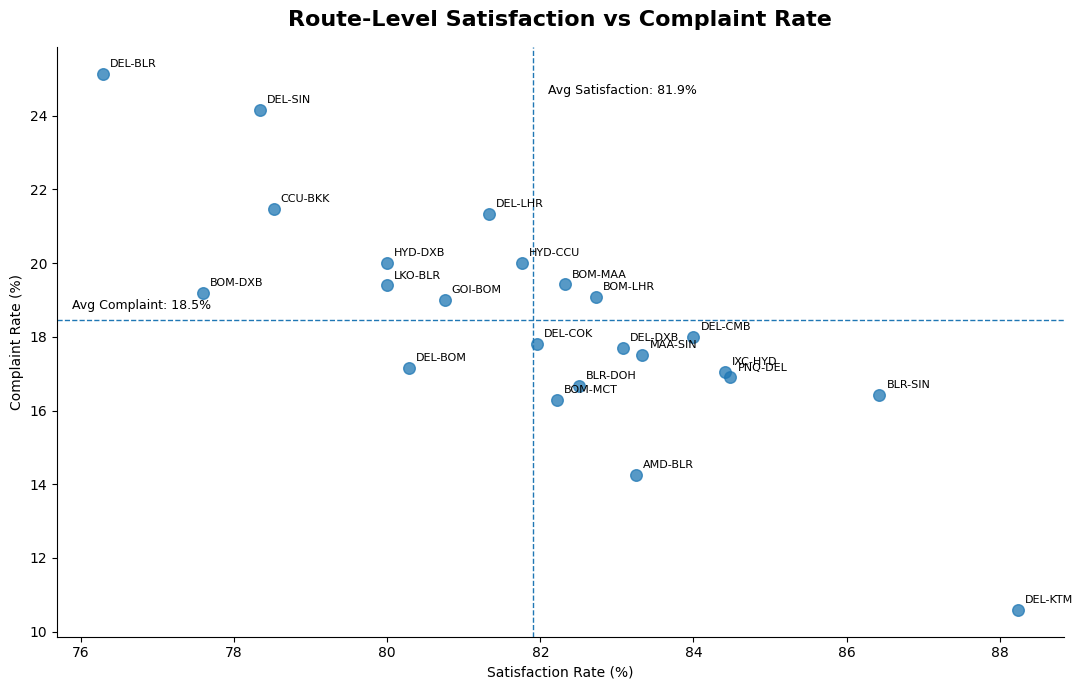

In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create route-level satisfaction and complaint metrics
route_analysis = (
    eda_df
    .groupby("route")
    .agg(
        passengers=("experiencekey", "count"),
        satisfied=("overallsatisfaction", lambda x: (x == "Satisfied").sum()),
        complaints=("complainttype", lambda x: x.notna().sum())
    )
    .reset_index()
)

# Calculate rates
route_analysis["satisfaction_rate"] = (
    route_analysis["satisfied"] /
    route_analysis["passengers"] * 100
)

route_analysis["complaint_rate"] = (
    route_analysis["complaints"] /
    route_analysis["passengers"] * 100
)

# Remove routes with insufficient observations if needed
route_analysis = route_analysis[
    route_analysis["passengers"] >= 20
].copy()

# -------------------------------------------------------
# Scatter Plot
# -------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(
    route_analysis["satisfaction_rate"],
    route_analysis["complaint_rate"],
    s=70,
    alpha=0.75
)

# Add route labels
for _, row in route_analysis.iterrows():
    ax.annotate(
        row["route"],
        (
            row["satisfaction_rate"],
            row["complaint_rate"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

# -------------------------------------------------------
# Add average reference lines
# -------------------------------------------------------

avg_satisfaction = route_analysis["satisfaction_rate"].mean()
avg_complaint = route_analysis["complaint_rate"].mean()

ax.axvline(
    avg_satisfaction,
    linestyle="--",
    linewidth=1
)

ax.axhline(
    avg_complaint,
    linestyle="--",
    linewidth=1
)

# -------------------------------------------------------
# Labels
# -------------------------------------------------------

ax.set_title(
    "Route-Level Satisfaction vs Complaint Rate",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Satisfaction Rate (%)")
ax.set_ylabel("Complaint Rate (%)")

# Clean appearance
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Reference line labels
ax.text(
    avg_satisfaction + 0.2,
    ax.get_ylim()[1] * 0.95,
    f"Avg Satisfaction: {avg_satisfaction:.1f}%",
    fontsize=9
)

ax.text(
    ax.get_xlim()[0] + 0.2,
    avg_complaint + 0.3,
    f"Avg Complaint: {avg_complaint:.1f}%",
    fontsize=9
)


# -------------------------------------------------------
# Trendline
# -------------------------------------------------------

# x = route_analysis["satisfaction_rate"]
# y = route_analysis["complaint_rate"]

# slope, intercept = np.polyfit(x, y, 1)

# x_line = np.linspace(x.min(), x.max(), 100)
# y_line = slope * x_line + intercept

# ax.plot(
#     x_line,
#     y_line,
#     linestyle="--",
#     linewidth=2,
#     label="Trendline"
# )

# ax.legend()

plt.tight_layout()
plt.show()

In [108]:
correlation = route_analysis[
    ["satisfaction_rate", "complaint_rate"]
].corr().iloc[0, 1]

print(f"Route-level correlation: {correlation:.3f}")

Route-level correlation: -0.823


- Key Business Insight - Routes with higher satisfaction generally experience lower complaint rates, indicating that customer experience quality is strongly associated with complaint reduction.

# Final EDA Summary Table ⭐

In [126]:
import pandas as pd

eda_final_summary = pd.DataFrame({
    "Metric": [
        "Total Passengers",
        "Satisfaction Rate",
        "Average Recommendation Score",
        "Standard NPS",
        "Average Delay",
        "Complaint Rate",
        "Average Fare",
        "Total Revenue",
    ],
    "Value": [
        f"{len(eda_df):,}",
        f"{(eda_df['overallsatisfaction'] == 'Satisfied').mean() * 100:.2f}%",
        f"{eda_df['nps'].mean():.2f}",
        f"{standard_nps:.2f}",
        f"{eda_df['delay'].mean():.2f} mins",
        f"{eda_df['complainttype'].notna().mean() * 100:.2f}%",
        f"${eda_df['fare'].mean():,.2f}",
        f"${eda_df['total_revenue'].sum():,.2f}",
    ],
})

eda_final_summary

,Metric,Value
0,Total Passengers,"5,000"
1,Satisfaction Rate,81.68%
2,Average Recommendation Score,7.61
3,Standard NPS,6.44
4,Average Delay,19.39 mins
5,Complaint Rate,18.50%
6,Average Fare,"$9,551.21"
7,Total Revenue,"$55,577,294.00"


# ⭐ Final EDA Findings

# Key EDA Findings

## Passenger Experience

1. Overall passenger satisfaction is approximately 81.68%.

2. Flight delay shows a strong relationship with passenger satisfaction,
   with satisfaction declining as delay severity increases.

3. Complaint rates increase with increasing delay severity.

## Service Quality

4. WiFi and Entertainment are among the weaker-rated service dimensions.

5. Service-rating differences between satisfied and unsatisfied passengers
   help identify potential experience drivers.

6. Seat Comfort represents an important complaint area despite not being
   the lowest-rated service dimension.

## Customer Segmentation

7. Satisfaction differences across customer types are relatively modest.

8. Loyalty tiers show differences in satisfaction, NPS and complaint rates,
   but the differences are not extreme.

## Operations

9. Domestic and international routes exhibit different operational and
   financial characteristics.

10. Route-level analysis identifies routes with combinations of lower
    satisfaction, higher complaint rates and operational delays.

## Revenue

11. Revenue exposure varies significantly by cabin class and route.

12. Revenue and passenger experience should be evaluated together when
    prioritizing operational interventions.

## Modeling Preparation

13. Delay, service ratings, customer characteristics, route characteristics
    and revenue-related variables provide candidate features for the
    predictive modeling stage.